# Demo. Two Patch Lattice Surgery — Rotated Surface Code

Rotated-CSS-surface-code analogue of `two_patch_LS.ipynb`. Joint Pauli measurement ($\bar X_1\bar X_2$ / $\bar Z_1\bar Z_2$) by merging and splitting two rotated surface code patches via `RotatedTwoPatchCoupler`.

In [7]:
import sys, io, contextlib
from pathlib import Path

ROOT = Path('../..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import stim

from lightstim.qec_code.surface_code.rotated import (
    RotatedSurfaceCode,
    RotatedSurfaceCodeExtractionBlock,
    RotatedTwoPatchCoupler,
)
from lightstim.protocols.two_patch_ls import TwoPatchLSExperiment

def build_quiet(exp):
    """Build a circuit, suppressing the protocol's progress prints."""
    with contextlib.redirect_stdout(io.StringIO()):
        return exp.build()

## Two Patch LS — Rotated Surface Code

To drive the rotated code, pass three classes to `TwoPatchLSExperiment`:
`code_patch_class=RotatedSurfaceCode`, `coupler_protocol=RotatedTwoPatchCoupler()`, `extraction_block_class=RotatedSurfaceCodeExtractionBlock`.

**Layout (verified by Stim peek; matches the unrotated convention).** Because the rotated code has
$\bar X$ vertical / $\bar Z$ horizontal, measuring $\bar Z_1\bar Z_2$ needs a **vertical stack** and
$\bar X_1\bar X_2$ a **side-by-side** placement:

| measurement | patch placement | `offset` |
|---|---|---|
| $\bar Z_1\bar Z_2$ (`ZZ`) | vertical stack | `(0, 2d+2)` |
| $\bar X_1\bar X_2$ (`XX`) | side-by-side | `(2d+2, 0)` |

Rotated patches need **no rotation/transpose** (`rotate_patch1=False`). Use **complementary** init bases
for the two patches (e.g. `ZZ` → `X`,`Z`); preparing both in the merge basis over-determines the joint logical.

## Example 1: $\bar X_1 \bar X_2$ Measurement (vertical stack)

Number of logical observables: 1


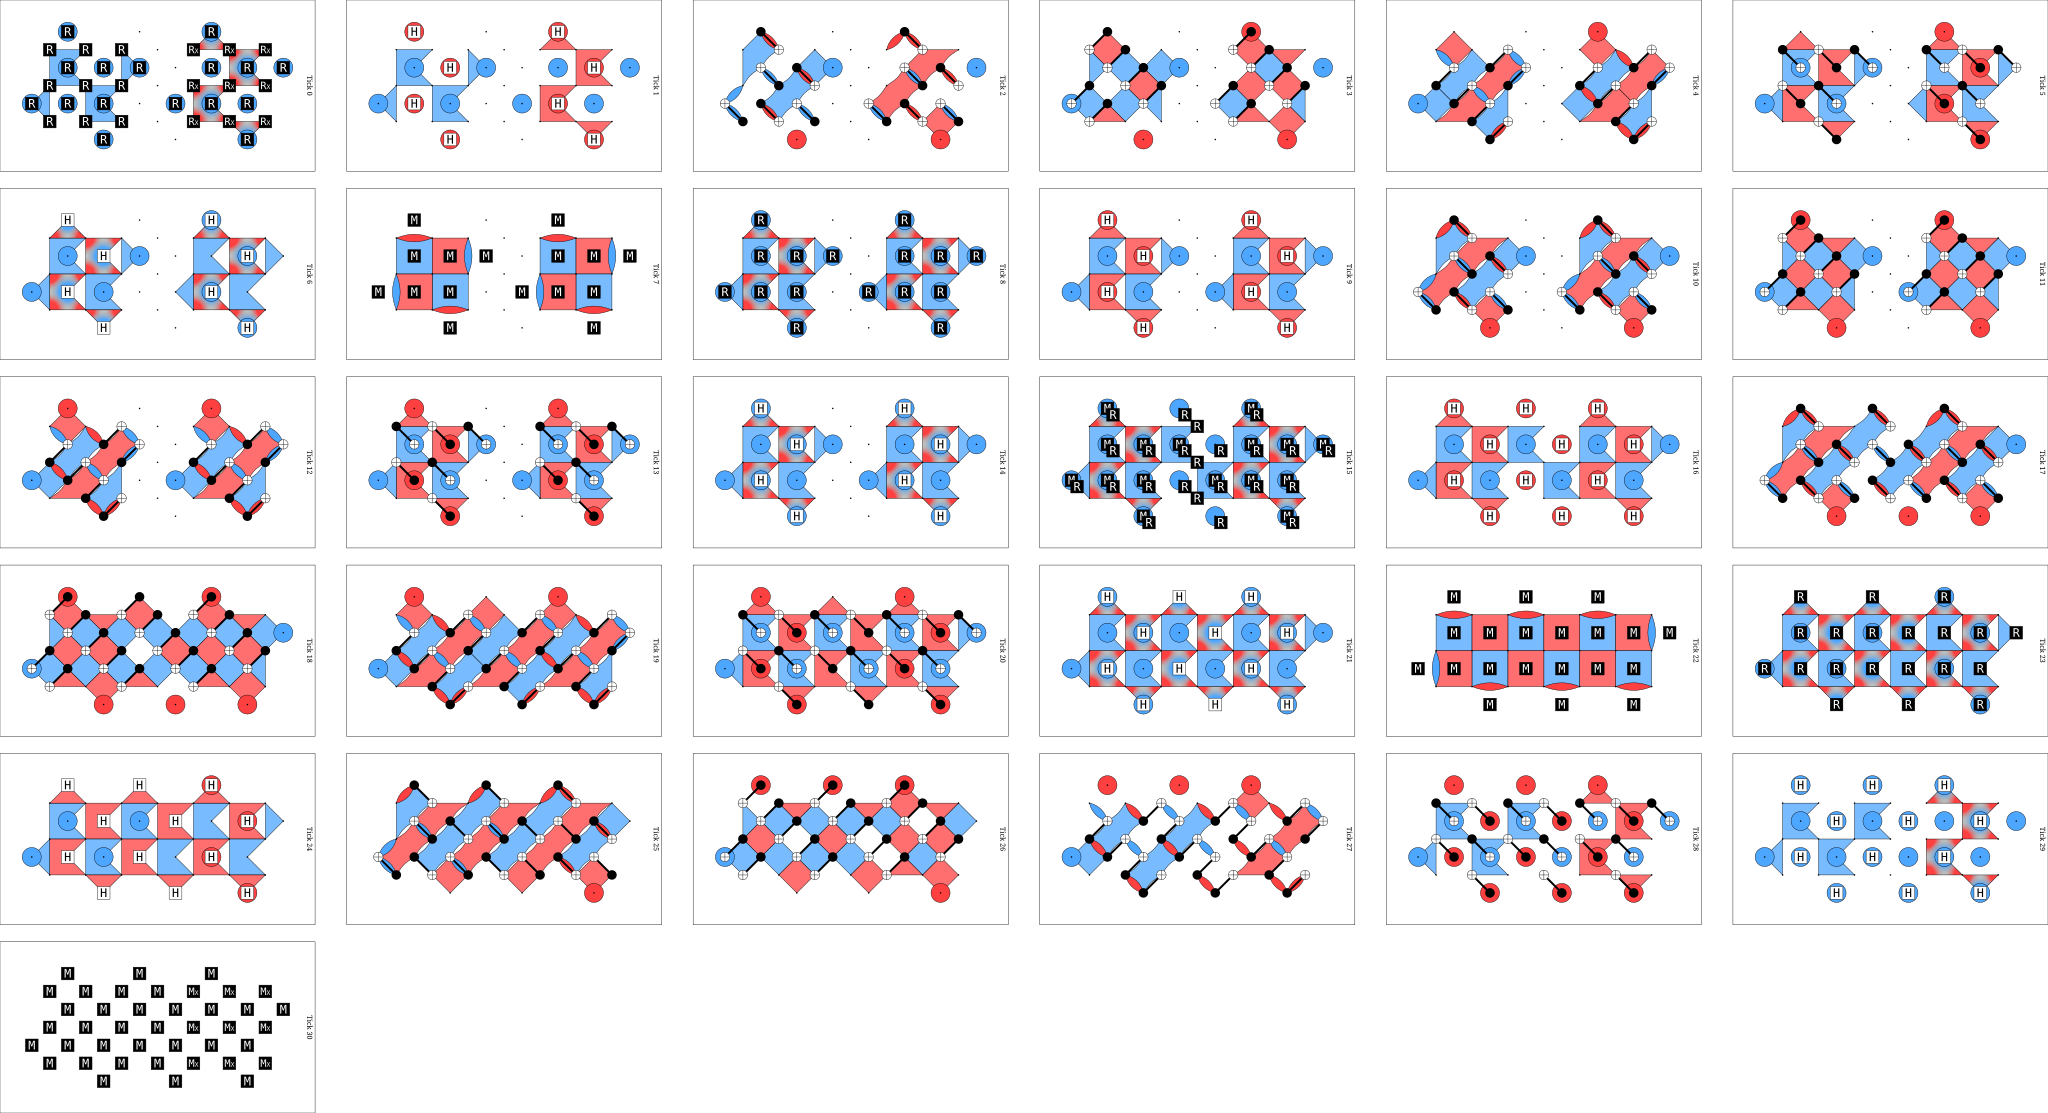

In [8]:
experiment_xx = TwoPatchLSExperiment(
    patch1_config={"distance": 3},
    patch2_config={"distance": 3},
    offset=(8, 0),                       # XX merge = side-by-side: (2d+2, 0)
    interaction_type="XX",
    code_patch_class=RotatedSurfaceCode,
    coupler_protocol=RotatedTwoPatchCoupler(),
    extraction_block_class=RotatedSurfaceCodeExtractionBlock,
    initial_state_patch1="Z",            # complementary bases for the joint X measurement
    initial_state_patch2="X",
    measure_state_patch1="Z",
    measure_state_patch2="X",
    rounds=2,
    rotate_patch1=False,                 # rotated patches need no rotation/transpose
)

circuit = build_quiet(experiment_xx)
print("Number of logical observables:", circuit.num_observables)
circuit.diagram("detslice-with-ops-svg")

## Example 2: $\bar Z_1 \bar Z_2$ Measurement (side-by-side)

Number of logical observables: 1


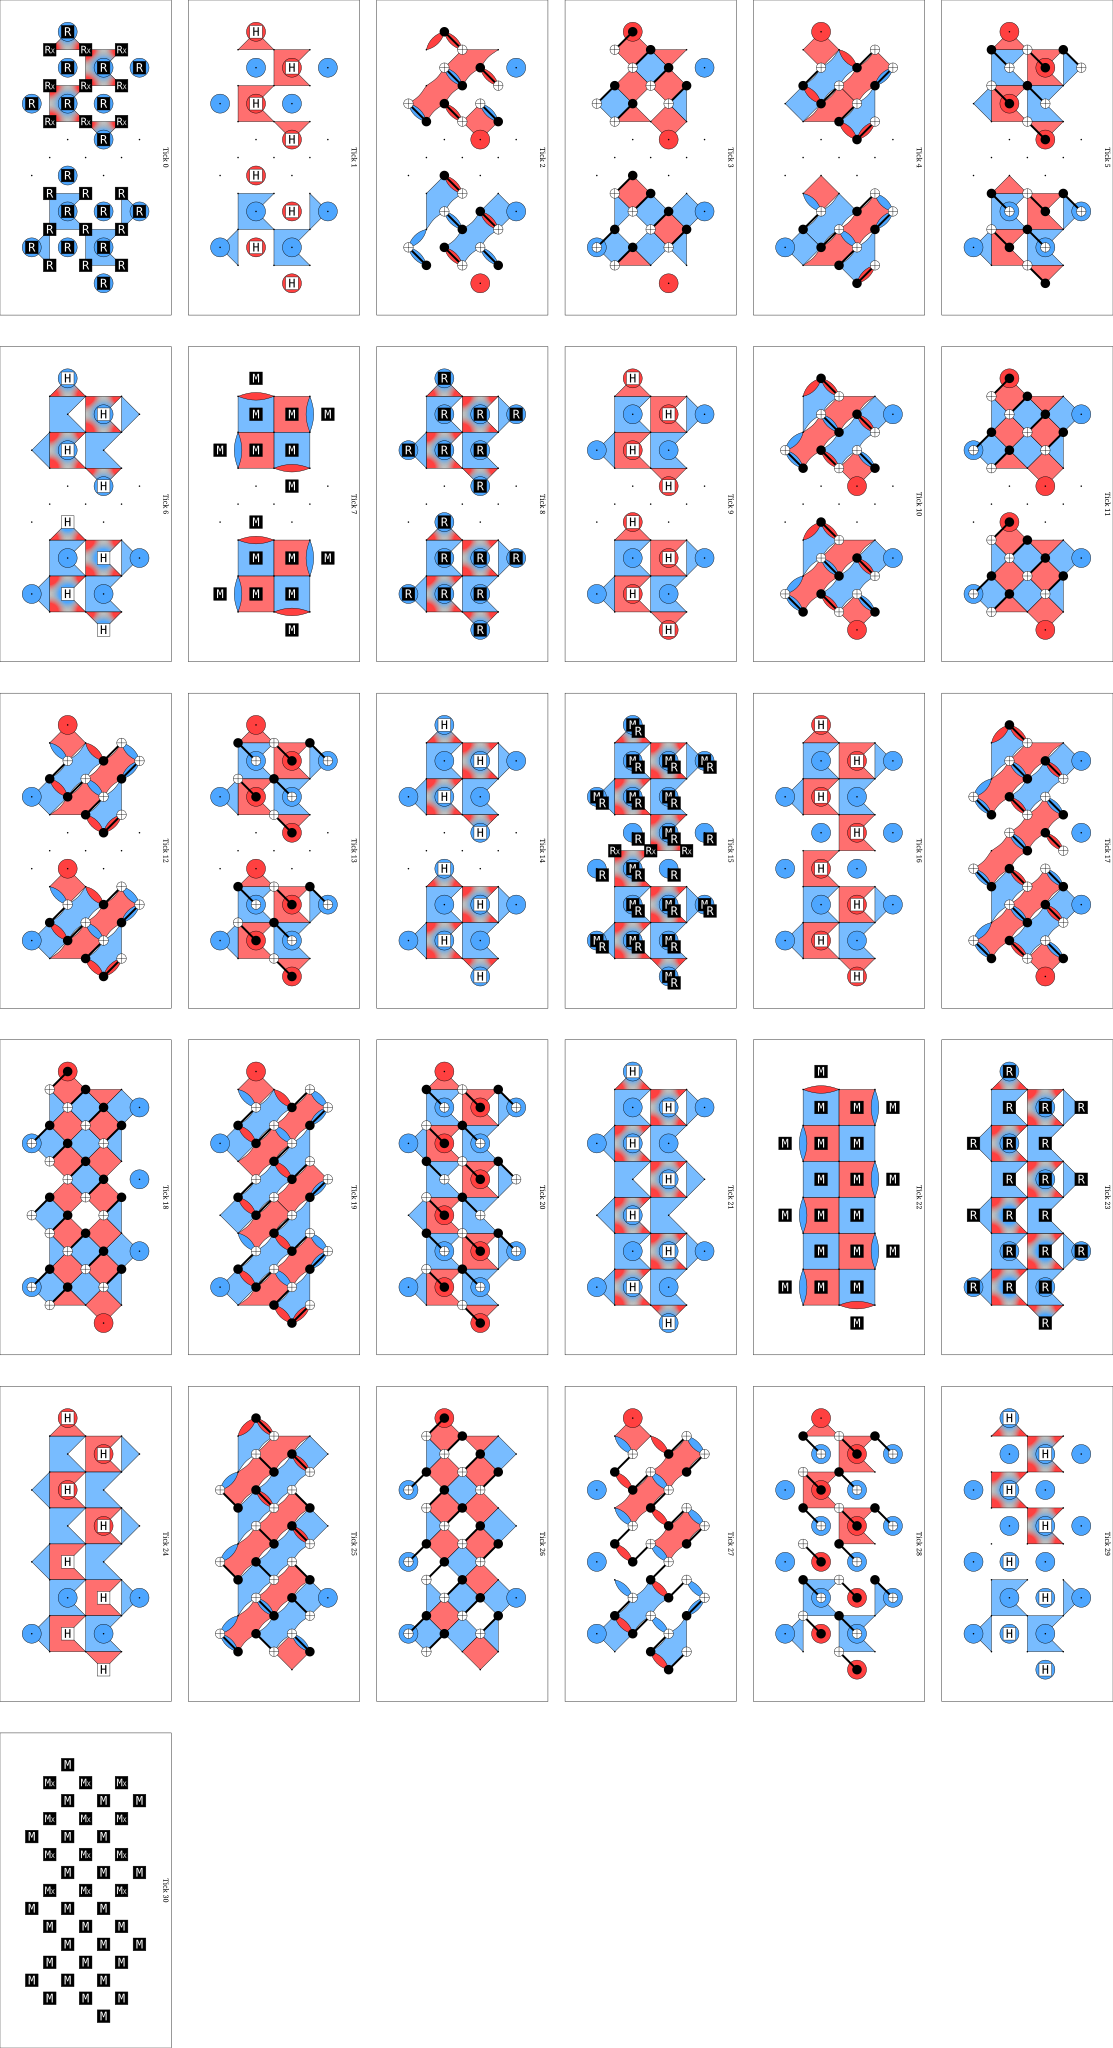

In [9]:
experiment_zz = TwoPatchLSExperiment(
    patch1_config={"distance": 3},
    patch2_config={"distance": 3},
    offset=(0, 8),                       # ZZ merge = vertical stack: (0, 2d+2)
    interaction_type="ZZ",
    code_patch_class=RotatedSurfaceCode,
    coupler_protocol=RotatedTwoPatchCoupler(),
    extraction_block_class=RotatedSurfaceCodeExtractionBlock,
    initial_state_patch1="X",
    initial_state_patch2="Z",
    measure_state_patch1="X",
    measure_state_patch2="Z",
    rounds=2,
    rotate_patch1=False,
)

circuit_zz = build_quiet(experiment_zz)
print("Number of logical observables:", circuit_zz.num_observables)
circuit_zz.diagram("detslice-with-ops-svg")

## Example 3: Rectangular Patches, $\bar Z_1\bar Z_2$

A `ZZ` merge (vertical stack) requires the two patches to share `distance_z` (the transverse distance);
`distance_x` may differ. The merged code has `distance_x = d_{x1} + d_{x2} + 1`.

Number of logical observables: 1


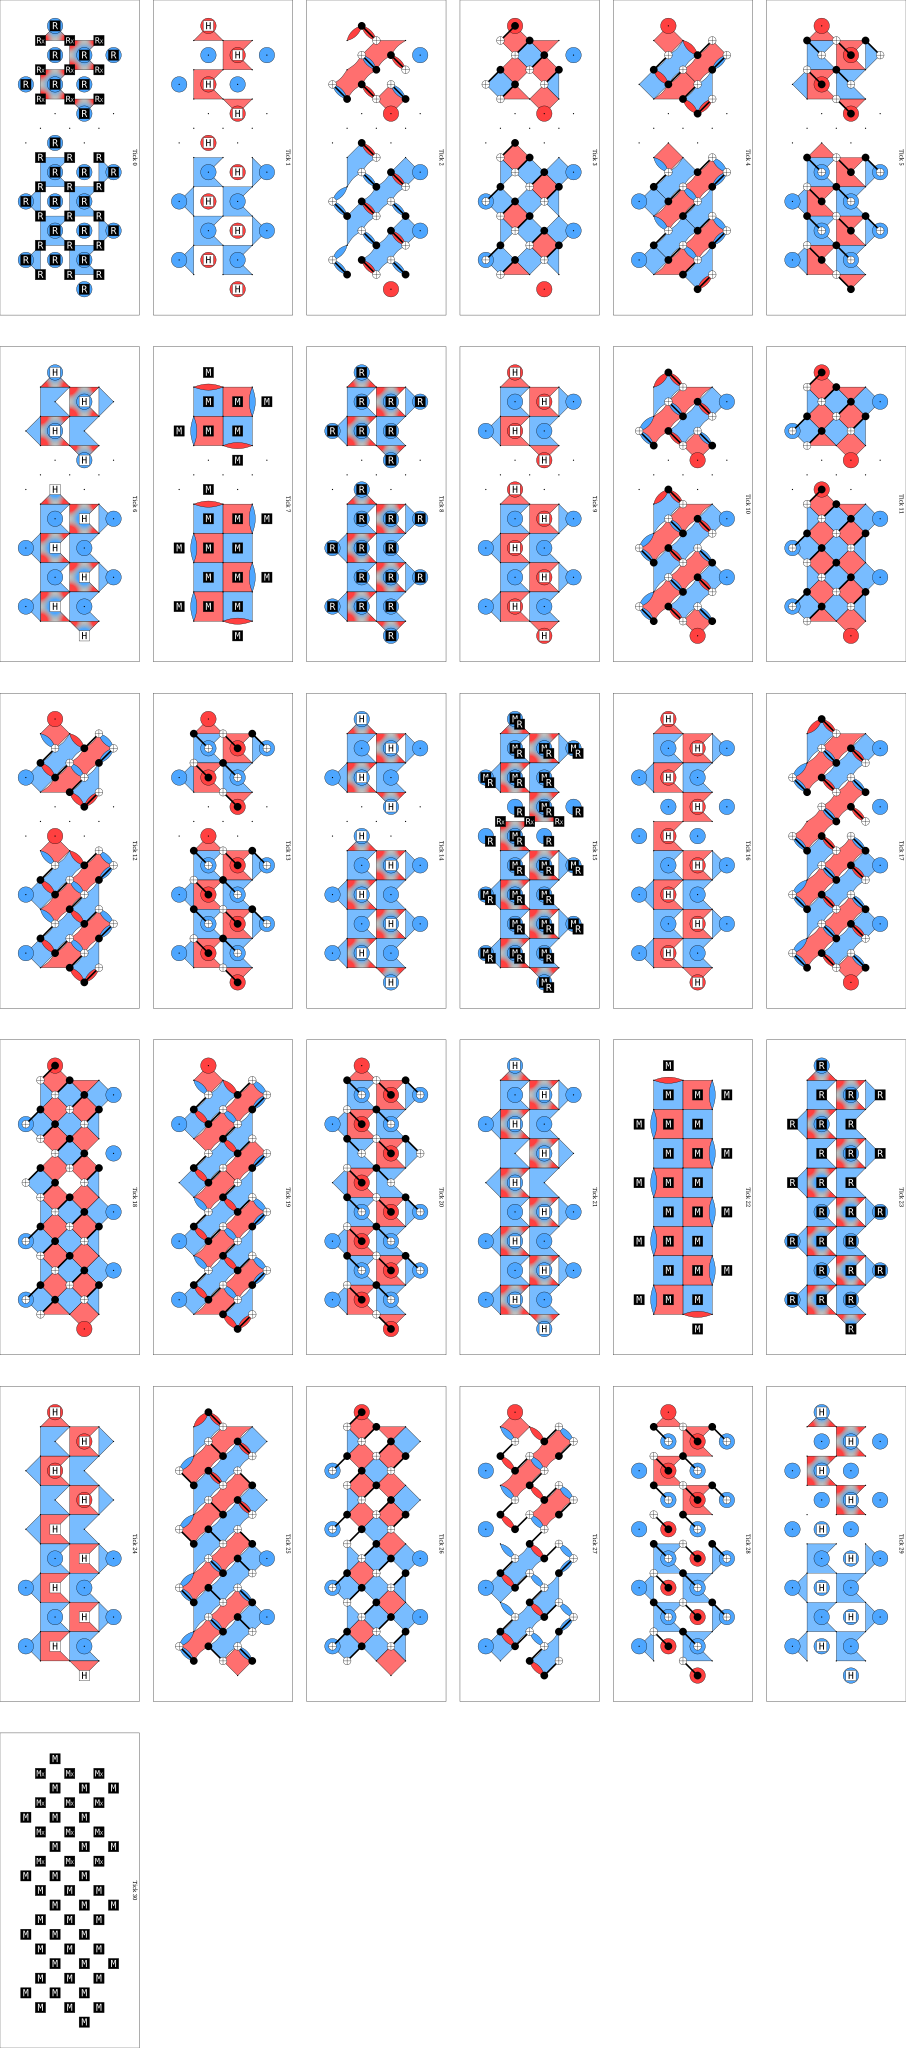

In [10]:
experiment_rect = TwoPatchLSExperiment(
    patch1_config={"distance_z": 3, "distance_x": 3},
    patch2_config={"distance_z": 3, "distance_x": 5},
    offset=(0, 8),                       # gap set by patch1's distance_x: 2*d_x1 + 2
    interaction_type="ZZ",
    code_patch_class=RotatedSurfaceCode,
    coupler_protocol=RotatedTwoPatchCoupler(),
    extraction_block_class=RotatedSurfaceCodeExtractionBlock,
    initial_state_patch1="X",
    initial_state_patch2="Z",
    measure_state_patch1="X",
    measure_state_patch2="Z",
    rounds=2,
    rotate_patch1=False,
)

circuit_rect = build_quiet(experiment_rect)
print("Number of logical observables:", circuit_rect.num_observables)
circuit_rect.diagram("detslice-with-ops-svg")

## Example 4: It decodes — logical error rate vs $p$

Circuit-level depolarizing noise, `rounds = d`, PyMatching decoder. Below threshold the LER is suppressed with distance — confirming the rotated merge is genuinely error-correcting. (Quick demo sweep; for the full high-statistics version see `benchmarks/rotated_ls/run_and_plot.py`.)

d=3: 1e-03->1.8e-03  2e-03->5.0e-03  3e-03->1.2e-02  5e-03->3.2e-02  7e-03->6.5e-02  1e-02->1.1e-01
d=5: 1e-03->2.7e-04  2e-03->1.8e-03  3e-03->5.5e-03  5e-03->3.0e-02  7e-03->7.3e-02  1e-02->1.6e-01
d=7: 1e-03->1.7e-05  2e-03->6.2e-04  3e-03->2.6e-03  5e-03->2.1e-02  7e-03->7.4e-02  1e-02->2.2e-01


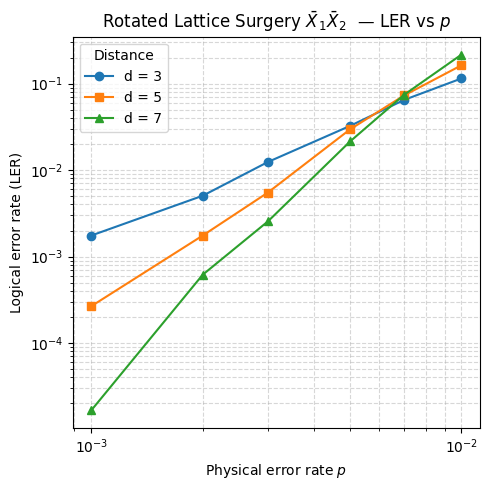

In [11]:
import pymatching
import matplotlib.pyplot as plt
from lightstim.noise.config import NoiseConfig

def ler(d, p, max_shots=60000, max_errors=50, batch=20000):
    noise = NoiseConfig(p_meas=p, p_reset=p, p_1q=p, p_2q=p, p_idle=p)
    exp = TwoPatchLSExperiment(
        patch1_config={"distance": d}, patch2_config={"distance": d},
        offset=(2 * d + 2, 0), interaction_type="XX",
        code_patch_class=RotatedSurfaceCode, coupler_protocol=RotatedTwoPatchCoupler(),
        extraction_block_class=RotatedSurfaceCodeExtractionBlock,
        initial_state_patch1="Z", initial_state_patch2="X",
        measure_state_patch1="Z", measure_state_patch2="X",
        rounds=d, noise_params=noise, noise_model="circuit_level", rotate_patch1=False)
    circ = build_quiet(exp)
    matcher = pymatching.Matching.from_detector_error_model(
        circ.detector_error_model(decompose_errors=True))
    sampler = circ.compile_detector_sampler()
    shots = errors = 0
    while shots < max_shots and errors < max_errors:
        n = min(batch, max_shots - shots)
        dets, obs = sampler.sample(n, separate_observables=True)
        errors += int(np.sum(np.any(matcher.decode_batch(dets) != obs, axis=1)))
        shots += n
    return errors / shots

ps = [1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2]
plt.figure(figsize=(5, 5))
for d, mk in [(3, "o"), (5, "s"), (7, "^")]:
    ys = [ler(d, p) for p in ps]
    plt.loglog(ps, ys, marker=mk, label=f"d = {d}")
    print(f"d={d}: " + "  ".join(f"{p:.0e}->{y:.1e}" for p, y in zip(ps, ys)))

plt.xlabel("Physical error rate $p$")
plt.ylabel("Logical error rate (LER)")
plt.title(r"Rotated Lattice Surgery $\bar X_1 \bar X_2$  — LER vs $p$")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(title="Distance")
plt.tight_layout()
plt.show()